# 1. Introduction
## 1.1 Installing necessary libraries

In [28]:
# CORE DATA HANDLING
import pandas as pd
import numpy as np
import re
from collections import Counter
from tqdm import tqdm

# NLP: TOKENIZATION, STOPWORDS, LEMMATIZATION
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams

# NLP: TOPIC MODELING & VECTORIZATION
import gensim
from gensim import corpora, models
from gensim.models import LdaModel
from gensim.corpora import Dictionary
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# DATA VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import pyLDAvis.gensim_models as gensimvis

# MACHINE LEARNING / DEEP LEARNING
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\buuqu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\buuqu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\buuqu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\buuqu\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 1.2. Loading the dataset
- Using pandas to read the csv file

In [29]:
# Load the dataset
df = pd.read_csv(('C:/Users/buuqu/OneDrive - The University Of Newcastle/LECTURE 2025/BUSA3001/BUSA3001 A2/iphone.csv'))
df

,Product ID,Country,Date,isVerified,Ratings,Reviews
0,B09G9D8KRQ,India,2/11/2021,True,5,The midnight colour is little bit like navy bl...
1,B09G9D8KRQ,United Arab Emirates,3/12/2021,True,2,Product looks good and super fast delivery but...
2,B09G9D8KRQ,India,6/11/2021,True,3,Apple Marketing has done quite a good job mont...
3,B09G9D8KRQ,India,6/11/2021,True,3,Apple Marketing has done quite a good job mont...
4,B09G9D8KRQ,United Arab Emirates,7/10/2021,True,5,Just as described. FaceTime included.
...,...,...,...,...,...,...
1160,B09G9D8KRQ,India,12/9/2024,True,5,NaN
1161,B09G9D8KRQ,United States,12/9/2024,True,1,"I purchased this phone 3 days back, which got ..."
1162,B09G9D8KRQ,United States,12/9/2024,True,1,"I have contacted amazon, they refuse to help b..."
1163,B09G9D8KRQ,United States,12/9/2024,True,5,Perfect condition. Works as it should. Price w...


## 1.3. Data Preparation: 
- Explore the data basis characteristics: shapes, datatype, missing values, descriptive statistics

In [30]:
# Shape
print("Shape of the dataset:", df.shape)

# Data types
print("\nData types:")
print(df.dtypes)

# Missing values and duplicate values
print("\nDuplicated values in each column:")
print(df.duplicated().sum())
print("\nMissing values in each column:")
print(df.isnull().sum())

# Descriptive statistics
print("\nDescriptive statistics:")
print(df.describe(include='all'))

Shape of the dataset: (1165, 6)

Data types:
Product ID    object
Country       object
Date          object
isVerified      bool
Ratings        int64
Reviews       object
dtype: object

Duplicated values in each column:
235

Missing values in each column:
Product ID     0
Country        0
Date           0
isVerified     0
Ratings        0
Reviews       37
dtype: int64

Descriptive statistics:
        Product ID Country        Date isVerified      Ratings Reviews
count         1165    1165        1165       1165  1165.000000    1128
unique           1       6         302          2          NaN     873
top     B09G9D8KRQ   India  12/10/2023       True          NaN    Good
freq          1165     853          17       1071          NaN      16
mean           NaN     NaN         NaN        NaN     3.766524     NaN
std            NaN     NaN         NaN        NaN     1.555528     NaN
min            NaN     NaN         NaN        NaN     1.000000     NaN
25%            NaN     NaN         N

- Handle missing values (drop or impute) if have
- Filter relevant columns (keep only rating, reviews, date columns)
- Convert ratings to sentiment labels
- Turn to datetime dtype

In [31]:
# Drop rows with missing values
df = df.dropna()
# Drop duplicates
df = df.drop_duplicates()
# Drop unnecessary columns
df1 = df.drop(columns=['Product ID', 'Product name', 'Helpful', 'isVerified', 'Country'], errors='ignore')# Ensure 'Date' column is datetime
# Convert 'Date' column to datetime with a consistent format
df1['Date'] = pd.to_datetime(df1['Date'], errors='coerce')

# Convert Ratings to Sentiment Labels
def convert_rating_to_sentiment(Ratings):
    if Ratings >= 4:
        return 'positive'
    else:
        return 'negative'

# Apply the function to create a new column 'Sentiment Results'
df1['Sentiment Results'] = df1['Ratings'].apply(convert_rating_to_sentiment)
df1


,Date,Ratings,Reviews,Sentiment Results
0,2021-02-11,5,The midnight colour is little bit like navy bl...,positive
1,2021-03-12,2,Product looks good and super fast delivery but...,negative
2,2021-06-11,3,Apple Marketing has done quite a good job mont...,negative
4,2021-07-10,5,Just as described. FaceTime included.,positive
5,2021-08-10,5,Good one n nice color…go for it camera feature...,positive
...,...,...,...,...
1154,2024-12-08,5,Phone in exa excellent condition no marks or s...,positive
1161,2024-12-09,1,"I purchased this phone 3 days back, which got ...",negative
1162,2024-12-09,1,"I have contacted amazon, they refuse to help b...",negative
1163,2024-12-09,5,Perfect condition. Works as it should. Price w...,positive


In [32]:
print(df.dtypes)

Product ID    object
Country       object
Date          object
isVerified      bool
Ratings        int64
Reviews       object
dtype: object


## 1.4. Exploratory Data Analysis (EDA)
- Show the Ratings distribution

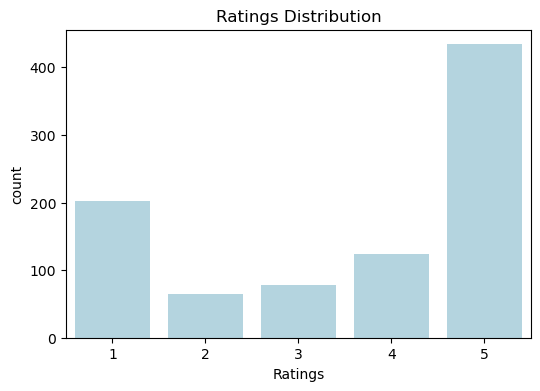

In [33]:
# Visualize Ratings Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Ratings', data=df1, color='lightblue')
plt.title('Ratings Distribution')
plt.show()

- Show the Sentiment Results Distribution

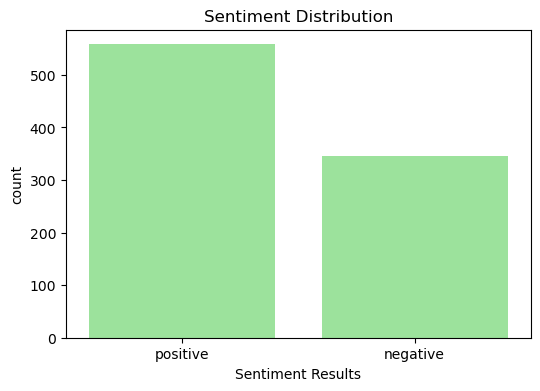

In [34]:
# Visualize Sentiment Results Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment Results', data=df1, order=['positive', 'negative'], color='lightgreen')
plt.title('Sentiment Distribution')
plt.show()

- Show the trend of number reviews between 2021 and 2024

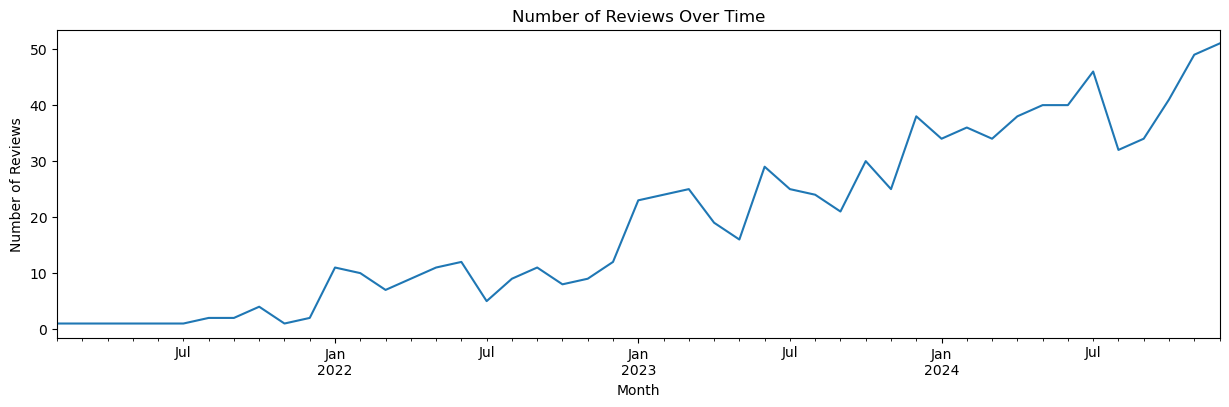

In [35]:
# Reviews Over Time
plt.figure(figsize=(15,4))
df1.groupby(df1['Date'].dt.to_period('M')).size().plot()
plt.title('Number of Reviews Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.show()


- Show the trend of number reviews by Sentiment Results between 2021 and 2024

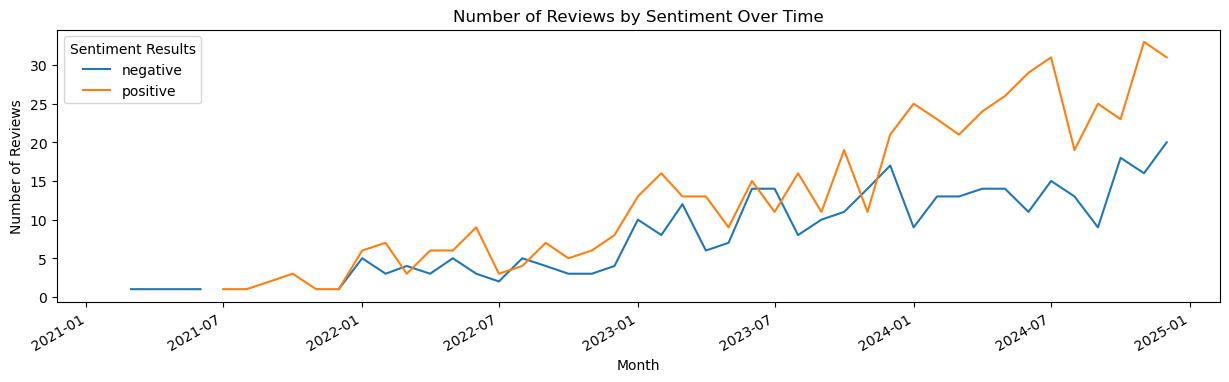

In [36]:
# Reviews by Sentiment Over Time
plt.figure(figsize=(15,4))

# Group and unstack
monthly_sentiment = df1.groupby([df1['Date'].dt.to_period('M'), 'Sentiment Results']).size().unstack()

# Convert PeriodIndex to timestamp for plotting
monthly_sentiment.index = monthly_sentiment.index.to_timestamp()

# Plot
monthly_sentiment.plot(ax=plt.gca())
plt.title('Number of Reviews by Sentiment Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment Results')
plt.show()

## 1.5. Textual Data Preprocessing
- Text CLeaning: Lowercase text, remove punctuation/ special chars
- Basic tokenization (splitting text into words, remove stopwords)


In [37]:
## Tokenize and lemmatize the reviews
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
stop_words.update(['phone', 'apple', 'product', 'iphone', 'amazon', 'android', 'device', 'even', 'also', 'get', 'nothing', 'user', 'would', 'good', 'muy', 'est', 'bater', 'tel', 'que'])

def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002700-\U000027BF"  # Dingbats
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def preprocess(text):
    text = remove_emojis(str(text))
    text = re.sub(r'[^a-zA-Z]', ' ', text.lower())
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\b\w{1}\b', '', text)  # Remove short words
    text = re.sub(r'\b\w{20,}\b', '', text)  # Remove long words
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    tokens = [word for word in tokens if len(word) > 2]  # Remove short tokens
    tokens = [word for word in tokens if word not in ['phone', 'apple', 'product', 'iphone', 'amazon', 'android', 'device', 'even', 'also', 'get', 'nothing', 'user', 'would', 'good', 'muy', 'est', 'bater', 'tel', 'que']]
    
    return ' '.join(tokens)

# Save the processed reviews
df1['Cleaned_review'] = df1['Reviews'].apply(preprocess)

In [38]:
df1

,Date,Ratings,Reviews,Sentiment Results,Cleaned_review
0,2021-02-11,5,The midnight colour is little bit like navy bl...,positive,midnight colour little bit like navy blue besi...
1,2021-03-12,2,Product looks good and super fast delivery but...,negative,look super fast delivery facetime please dont ...
2,2021-06-11,3,Apple Marketing has done quite a good job mont...,negative,marketing done quite job month month keep peop...
4,2021-07-10,5,Just as described. FaceTime included.,positive,described facetime included
5,2021-08-10,5,Good one n nice color…go for it camera feature...,positive,one nice color camera feature modified lover o...
...,...,...,...,...,...
1154,2024-12-08,5,Phone in exa excellent condition no marks or s...,positive,exa excellent condition mark scratch battery h...
1161,2024-12-09,1,"I purchased this phone 3 days back, which got ...",negative,purchased day back got delivered today turned ...
1162,2024-12-09,1,"I have contacted amazon, they refuse to help b...",negative,contacted refuse help outside day window week ...
1163,2024-12-09,5,Perfect condition. Works as it should. Price w...,positive,perfect condition work price fair


In [39]:
# Ensure 'tokens' column exists
df1['tokens'] = df1['Cleaned_review'].apply(lambda x: x.split())
df1

,Date,Ratings,Reviews,Sentiment Results,Cleaned_review,tokens
0,2021-02-11,5,The midnight colour is little bit like navy bl...,positive,midnight colour little bit like navy blue besi...,"[midnight, colour, little, bit, like, navy, bl..."
1,2021-03-12,2,Product looks good and super fast delivery but...,negative,look super fast delivery facetime please dont ...,"[look, super, fast, delivery, facetime, please..."
2,2021-06-11,3,Apple Marketing has done quite a good job mont...,negative,marketing done quite job month month keep peop...,"[marketing, done, quite, job, month, month, ke..."
4,2021-07-10,5,Just as described. FaceTime included.,positive,described facetime included,"[described, facetime, included]"
5,2021-08-10,5,Good one n nice color…go for it camera feature...,positive,one nice color camera feature modified lover o...,"[one, nice, color, camera, feature, modified, ..."
...,...,...,...,...,...,...
1154,2024-12-08,5,Phone in exa excellent condition no marks or s...,positive,exa excellent condition mark scratch battery h...,"[exa, excellent, condition, mark, scratch, bat..."
1161,2024-12-09,1,"I purchased this phone 3 days back, which got ...",negative,purchased day back got delivered today turned ...,"[purchased, day, back, got, delivered, today, ..."
1162,2024-12-09,1,"I have contacted amazon, they refuse to help b...",negative,contacted refuse help outside day window week ...,"[contacted, refuse, help, outside, day, window..."
1163,2024-12-09,5,Perfect condition. Works as it should. Price w...,positive,perfect condition work price fair,"[perfect, condition, work, price, fair]"


## 1.6. Data Visualisation

### 1.6.1 Text Visualisation with Word Cloud (in general)

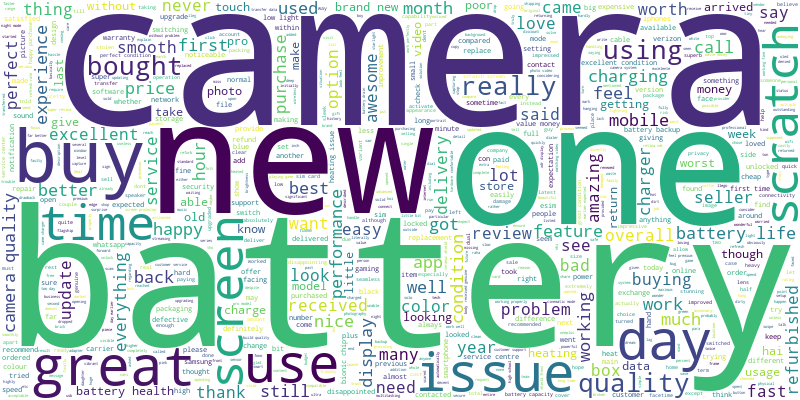

In [40]:
## Join the different processed titles together.
long_string = ','.join(list(df1['Cleaned_review'].values))

## Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color="white", max_words=1000, contour_width=3, contour_color='steelblue')

## Generate a word cloud
wordcloud.generate(long_string)

## Visualize the word cloud
wordcloud.to_image()

## 1.6.2. Frequency bar chart based on the Word Cloud (in general)

C:\Users\buuqu\AppData\Local\Temp\ipykernel_15384\3241596792.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='coolwarm')


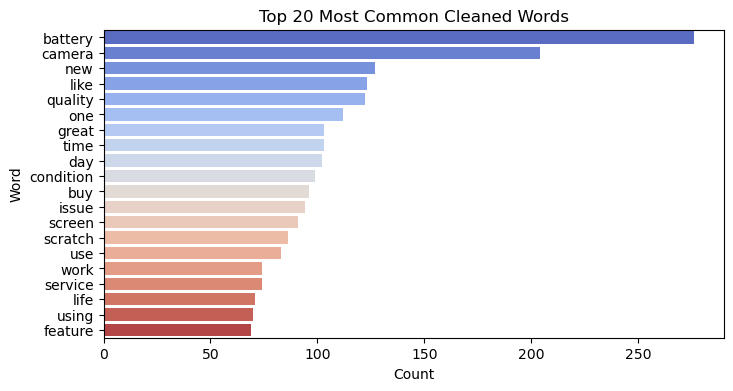

In [41]:
tokens_list = df1['tokens']  # Use the tokens column from df1
all_words = [word for tokens in tokens_list for word in tokens]
common_words = Counter(all_words).most_common(20)
words, counts = zip(*common_words)
plt.figure(figsize=(8,4))
sns.barplot(x=list(counts), y=list(words), palette='coolwarm')
plt.title('Top 20 Most Common Cleaned Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

## 1.6.3. Text Analysis with Word Cloud (by Sentiment Results)

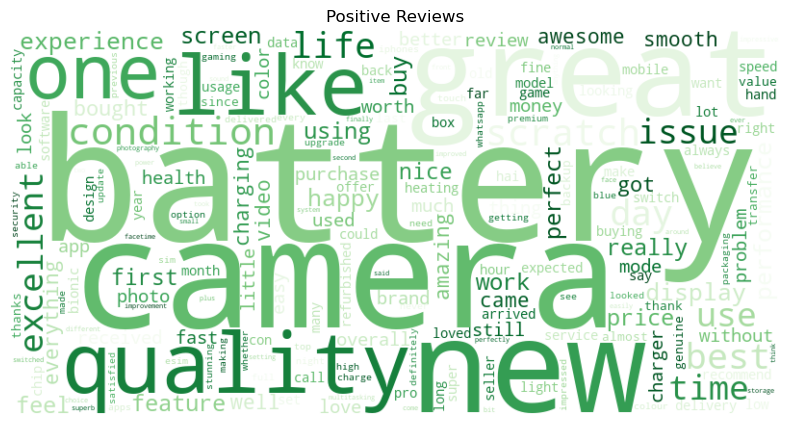

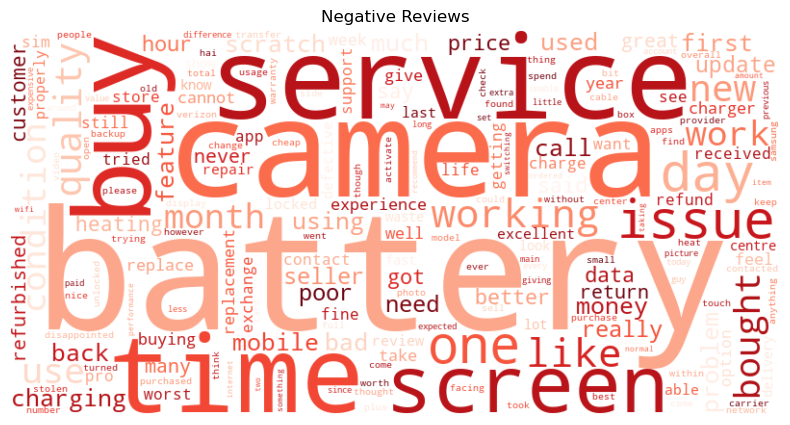

In [42]:
# Calculate Word Frequency by Sentiment
def get_word_freq(tokens_list):
    all_words = [word for tokens in tokens_list for word in tokens]
    return Counter(all_words)

positive_freq = get_word_freq(df1[df1['Sentiment Results'] == 'positive']['tokens'])
negative_freq = get_word_freq(df1[df1['Sentiment Results'] == 'negative']['tokens'])

# Word Cloud

def plot_custom_wordcloud(freq_dict, title, colormap='viridis'):
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color='white',
        colormap=colormap
    ).generate_from_frequencies(freq_dict)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Positive reviews (green theme)
plot_custom_wordcloud(positive_freq, "Positive Reviews", 'Greens')
# Negative reviews (red theme)
plot_custom_wordcloud(negative_freq, "Negative Reviews", 'Reds')

## 1.6.4. Frequecy bar chart based on Word Cloud (by Sentiment Results)

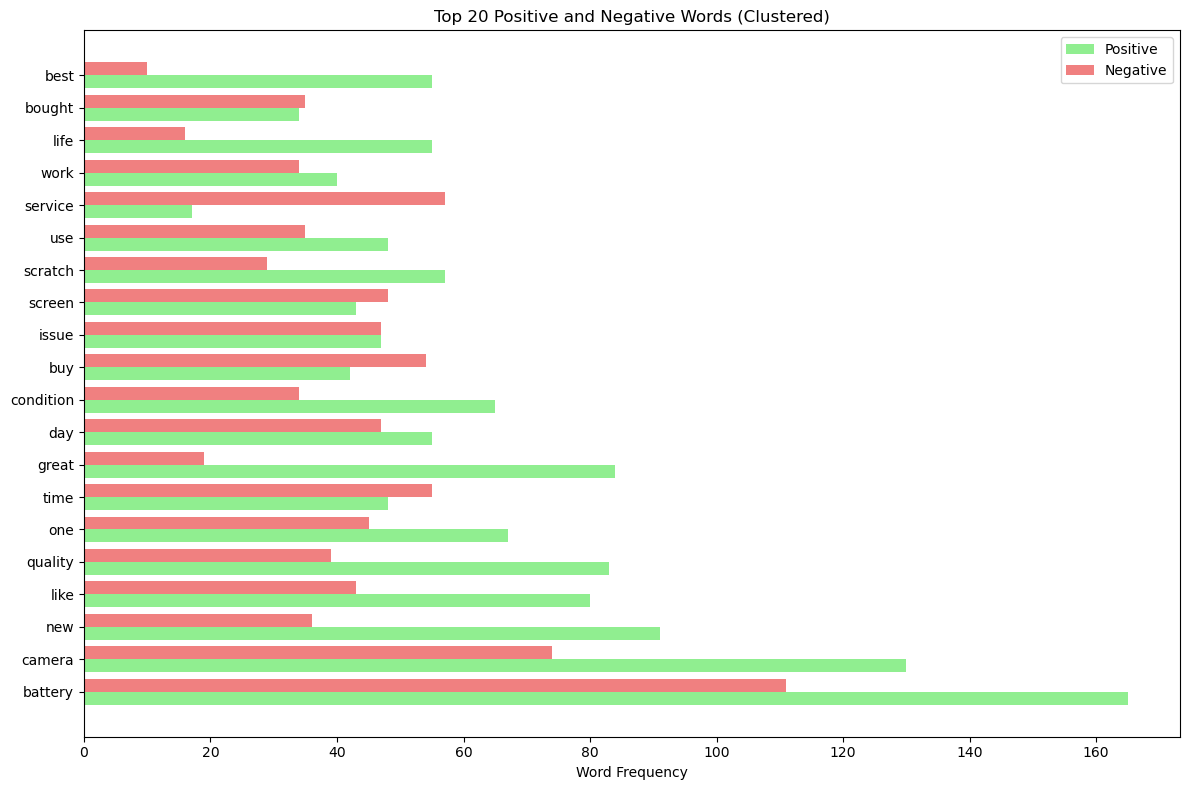

In [43]:

# Define positive_words and negative_words as the top 20 most common in each sentiment
positive_words = [w for w, _ in positive_freq.most_common(20)]
negative_words = [w for w, _ in negative_freq.most_common(20)]

# Ensure both lists have the same words for proper clustering
words = list(set(positive_words) | set(negative_words))
words.sort(key=lambda w: (positive_freq[w] + negative_freq[w]), reverse=True)
words = words[:20]  # Top 20 by total frequency

pos_counts = [positive_freq.get(w, 0) for w in words]
neg_counts = [negative_freq.get(w, 0) for w in words]

y = np.arange(len(words))
bar_width = 0.4

plt.figure(figsize=(12, 8))
plt.barh(y - bar_width/2, pos_counts, height=bar_width, color='lightgreen', label='Positive')
plt.barh(y + bar_width/2, neg_counts, height=bar_width, color='lightcoral', label='Negative')
plt.yticks(y, words)
plt.xlabel('Word Frequency')
plt.title('Top 20 Positive and Negative Words (Clustered)')
plt.legend()
plt.tight_layout()
plt.show()


## 1.6.5. The popular words in each year (2021 - 2024)

In [44]:
# Group the popular words by year
yearly_popular_words = df1.groupby(df1['Date'].dt.year)['Cleaned_review'].apply(list)

# Create a dictionary to store yearly word counts
yearly_word_counts = {}

for year, words in yearly_popular_words.items():
    all_year_text = ' '.join(words)
    yearly_word_counts[year] = Counter(all_year_text.split())

# Print the top 10 words for each year (Optional: Can be adjusted to more or fewer)
for year, counts in yearly_word_counts.items():
    print(f"\nTop 10 words for {year}:")
    print(counts.most_common(10))


Top 10 words for 2021:
[('fast', 4), ('great', 4), ('data', 4), ('look', 3), ('facetime', 3), ('transfer', 3), ('better', 3), ('battery', 3), ('life', 3), ('set', 3)]

Top 10 words for 2022:
[('battery', 40), ('camera', 39), ('quality', 21), ('time', 19), ('really', 18), ('buy', 18), ('great', 16), ('feel', 16), ('life', 14), ('one', 13)]

Top 10 words for 2023:
[('camera', 98), ('battery', 91), ('one', 57), ('new', 53), ('quality', 52), ('like', 51), ('day', 49), ('screen', 45), ('time', 43), ('use', 39)]

Top 10 words for 2024:
[('battery', 142), ('condition', 73), ('new', 68), ('camera', 65), ('scratch', 64), ('like', 58), ('great', 53), ('quality', 49), ('issue', 48), ('time', 41)]


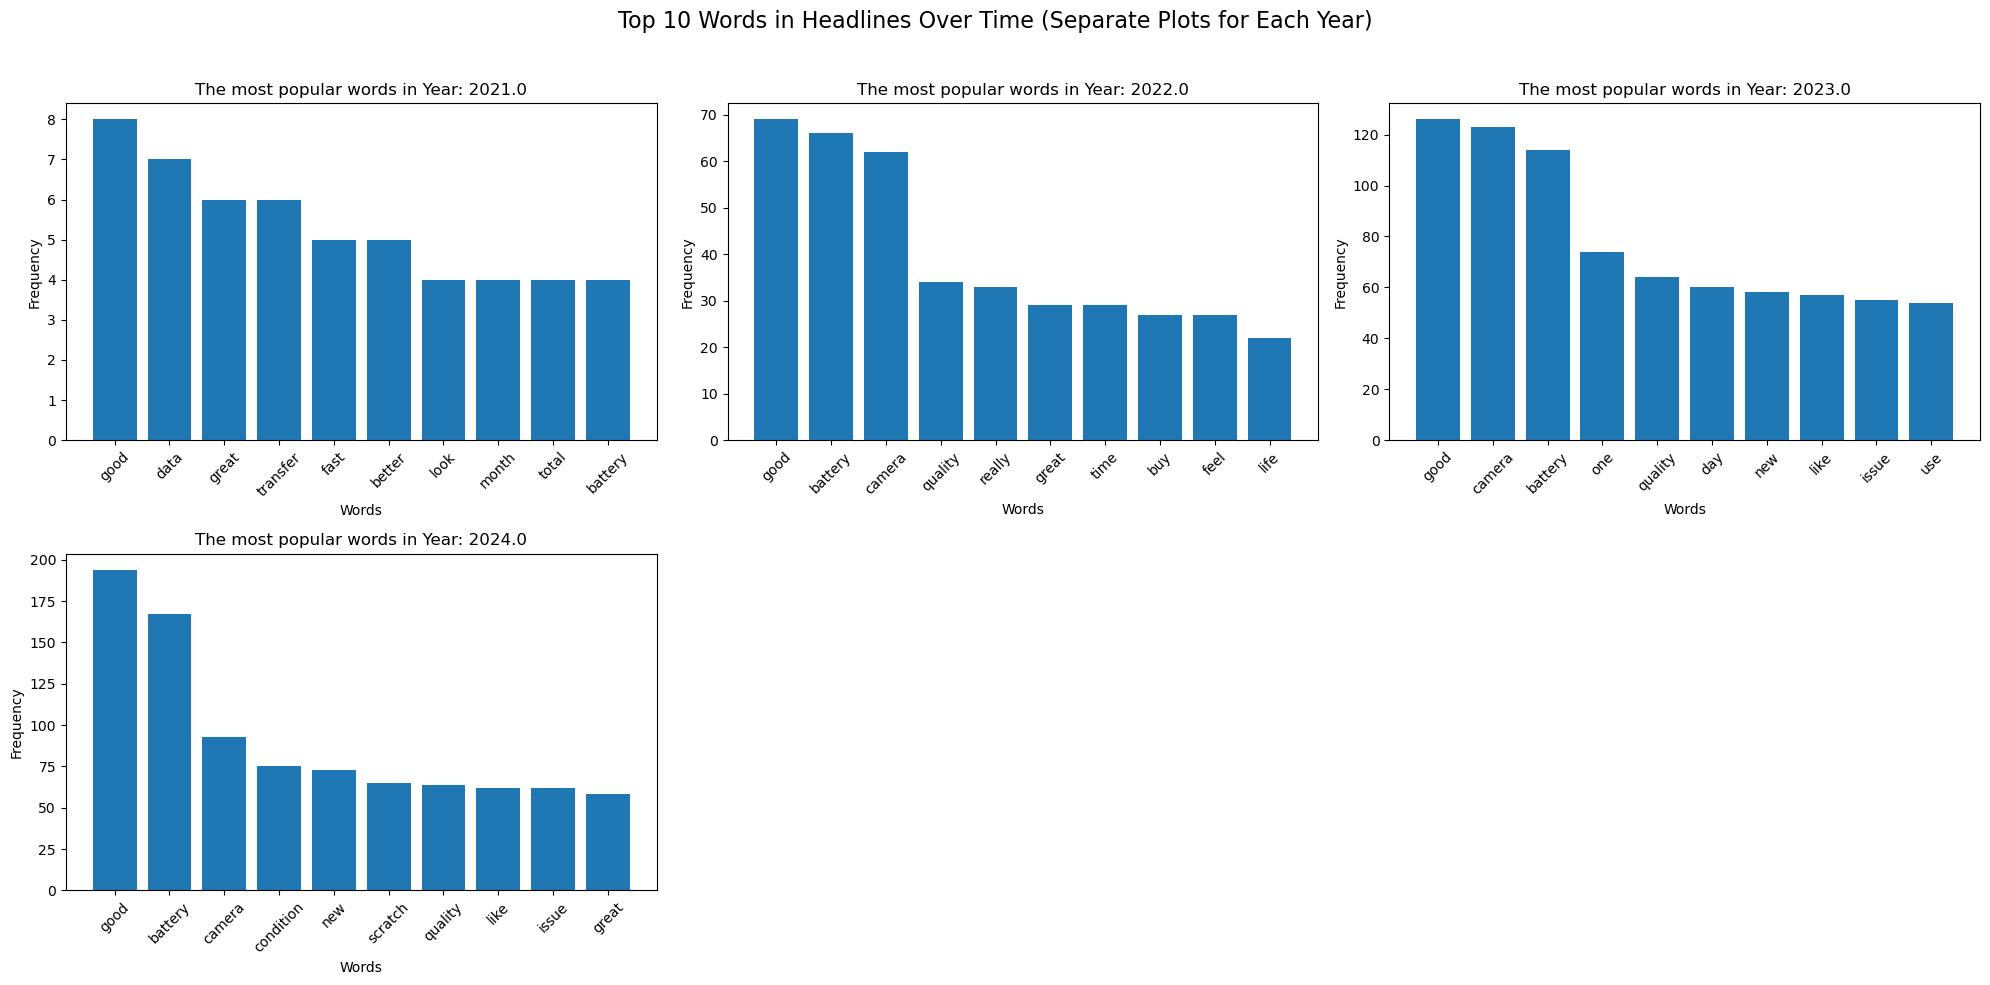

In [45]:
yearly_word_counts = {
  2021.0: [('good', 8), ('data', 7), ('great', 6), ('transfer', 6), ('fast', 5), ('better', 5), ('look', 4), ('month', 4), ('total', 4), ('battery', 4)],
  2022.0: [('good', 69), ('battery', 66), ('camera', 62), ('quality', 34), ('really', 33), ('great', 29), ('time', 29), ('buy', 27), ('feel', 27), ('life', 22)],
  2023.0: [('good', 126), ('camera', 123), ('battery', 114), ('one', 74), ('quality', 64), ('day', 60), ('new', 58), ('like', 57), ('issue', 55), ('use', 54)],
  2024.0: [('good', 194), ('battery', 167), ('camera', 93), ('condition', 75), ('new', 73), ('scratch', 65), ('quality', 64), ('like', 62), ('issue', 62), ('great', 58)], 
}

# Create subplots for each year
num_years = len(yearly_word_counts)
num_cols = 3  # Number of columns for subplots
num_rows = (num_years + num_cols - 1) // num_cols  # Calculate rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 5))
fig.suptitle('Top 10 Words in Headlines Over Time (Separate Plots for Each Year)', fontsize=16)

# Iterate through years and plot
for i, (year, word_counts) in enumerate(yearly_word_counts.items()):
    row = i // num_cols
    col = i % num_cols
    ax = axes[row, col]

    words, frequencies = zip(*word_counts)  # Unzip word_counts
    ax.bar(words, frequencies)

    ax.set_title(f'The most popular words in Year: {year}')
    ax.set_xlabel('Words')
    ax.set_ylabel('Frequency')
    ax.tick_params(axis='x', rotation=45)  # Changed 'horizontalalignment' to 'ha'

# Remove extra subplots if any
for i in range(num_years, num_rows * num_cols):
    fig.delaxes(axes[i // num_cols, i % num_cols])

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout
plt.show()

## 1.6.6. N-Grams

In [46]:
# For bigrams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=100)  # Limit to top 100 bigrams
bigram_counts = bigram_vectorizer.fit_transform(df1['Cleaned_review'])

# For trigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3), stop_words='english', max_features=100)  # Limit to top 100 trigrams
trigram_counts = trigram_vectorizer.fit_transform(df1['Cleaned_review'])

# Helper function to get top n-grams
def get_top_ngrams(counts, vectorizer, top_n=10):
    ngram_counts = counts.sum(axis=0).A1
    ngram_indices = ngram_counts.argsort()[::-1][:top_n]
    ngrams = [vectorizer.get_feature_names_out()[i] for i in ngram_indices]
    frequencies = [ngram_counts[i] for i in ngram_indices]
    return list(zip(ngrams, frequencies))

# Get top bigrams and trigrams
top_bigrams = get_top_ngrams(bigram_counts, bigram_vectorizer)
top_trigrams = get_top_ngrams(trigram_counts, trigram_vectorizer)

print(f"\nBigrams:")
for bigram, count in top_bigrams:
    print(f"{bigram}: {count}")

print(f"\nTrigrams:")
for trigram, count in top_trigrams:
    print(f"{trigram}: {count}")


Bigrams:
battery life: 67
camera quality: 43
battery health: 28
brand new: 26
excellent condition: 23
like new: 20
battery backup: 17
service centre: 14
value money: 14
bionic chip: 13

Trigrams:
super retina xdr: 7
retina xdr display: 6
great battery life: 4
feel premium hand: 4
lookingcharging fastand battery: 4
like brand new: 4
brand new scratch: 4
ceramic shield cover: 4
usage time hour: 4
experiencegood lookingcharging fastand: 4


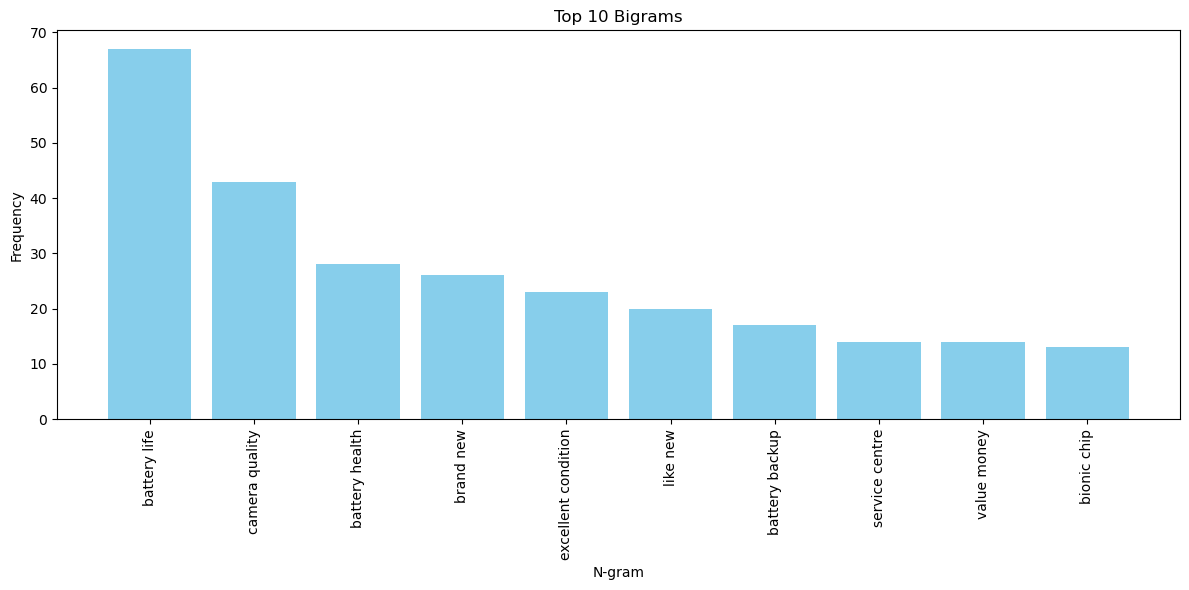

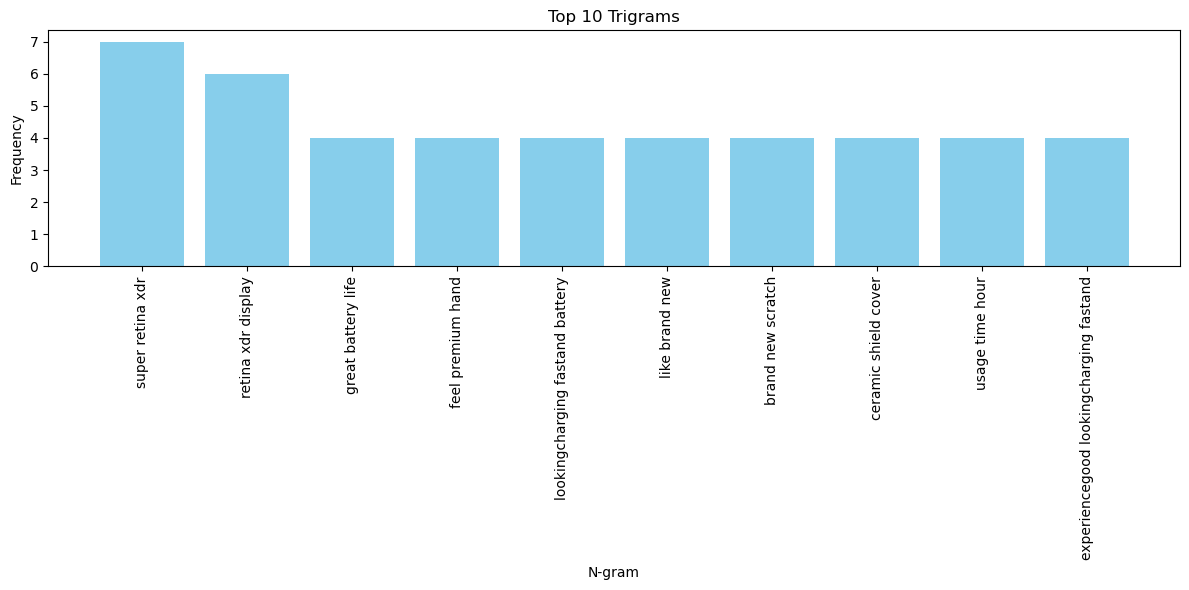

In [47]:
# Function to get top n-grams and their frequencies
def get_top_ngrams(counts, vectorizer, top_n=10):
    '''
    Returns a list of tuples, where each tuple contains an n-gram and its frequency.
    '''
    ngram_counts = counts.sum(axis=0).A1  # Sum frequencies across documents
    ngram_indices = ngram_counts.argsort()[::-1][:top_n]  # Get indices of top n-grams
    ngrams = [vectorizer.get_feature_names_out()[i] for i in ngram_indices]
    frequencies = [ngram_counts[i] for i in ngram_indices]
    return list(zip(ngrams, frequencies))

# Get top bigrams and trigrams
top_bigrams = get_top_ngrams(bigram_counts, bigram_vectorizer)
top_trigrams = get_top_ngrams(trigram_counts, trigram_vectorizer)

# Visualization using bar charts
import matplotlib.pyplot as plt

def plot_ngrams(ngrams, title):
    '''
    Plots a bar chart of n-gram frequencies.
    '''
    ngrams, frequencies = zip(*ngrams)
    plt.figure(figsize=(12, 6))
    plt.bar(ngrams, frequencies, color='skyblue')
    plt.xticks(rotation=90)
    plt.title(title)
    plt.xlabel('N-gram')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

plot_ngrams(top_bigrams, 'Top 10 Bigrams')
plot_ngrams(top_trigrams, 'Top 10 Trigrams')

# 2. Topic Modeling by LDA

Topic 0: battery, quality, camera, life, display, better, price, worth, fast, using
Topic 1: work, camera, used, money, issue, time, say, buy, sim, better
Topic 2: nice, screen, app, feature, use, seller, like, contact, file, make
Topic 3: scratch, battery, condition, came, excellent, happy, new, great, buy, bought
Topic 4: camera, feature, performance, hai, best, display, use, battery, video, feel
Topic 5: great, like, new, condition, battery, awesome, camera, work, arrived, brand
Topic 6: service, charging, battery, day, month, camera, buy, using, time, bought
Topic 7: battery, time, camera, money, quality, day, backup, love, value, feature
Topic 8: battery, new, hour, condition, day, like, service, camera, data, problem
Topic 9: working, heating, amazing, time, worst, charging, defective, tried, cable, used


C:\Users\buuqu\AppData\Local\Temp\ipykernel_15384\1121619021.py:40: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  topic_trend_quarterly = topic_trend.resample('Q').sum()


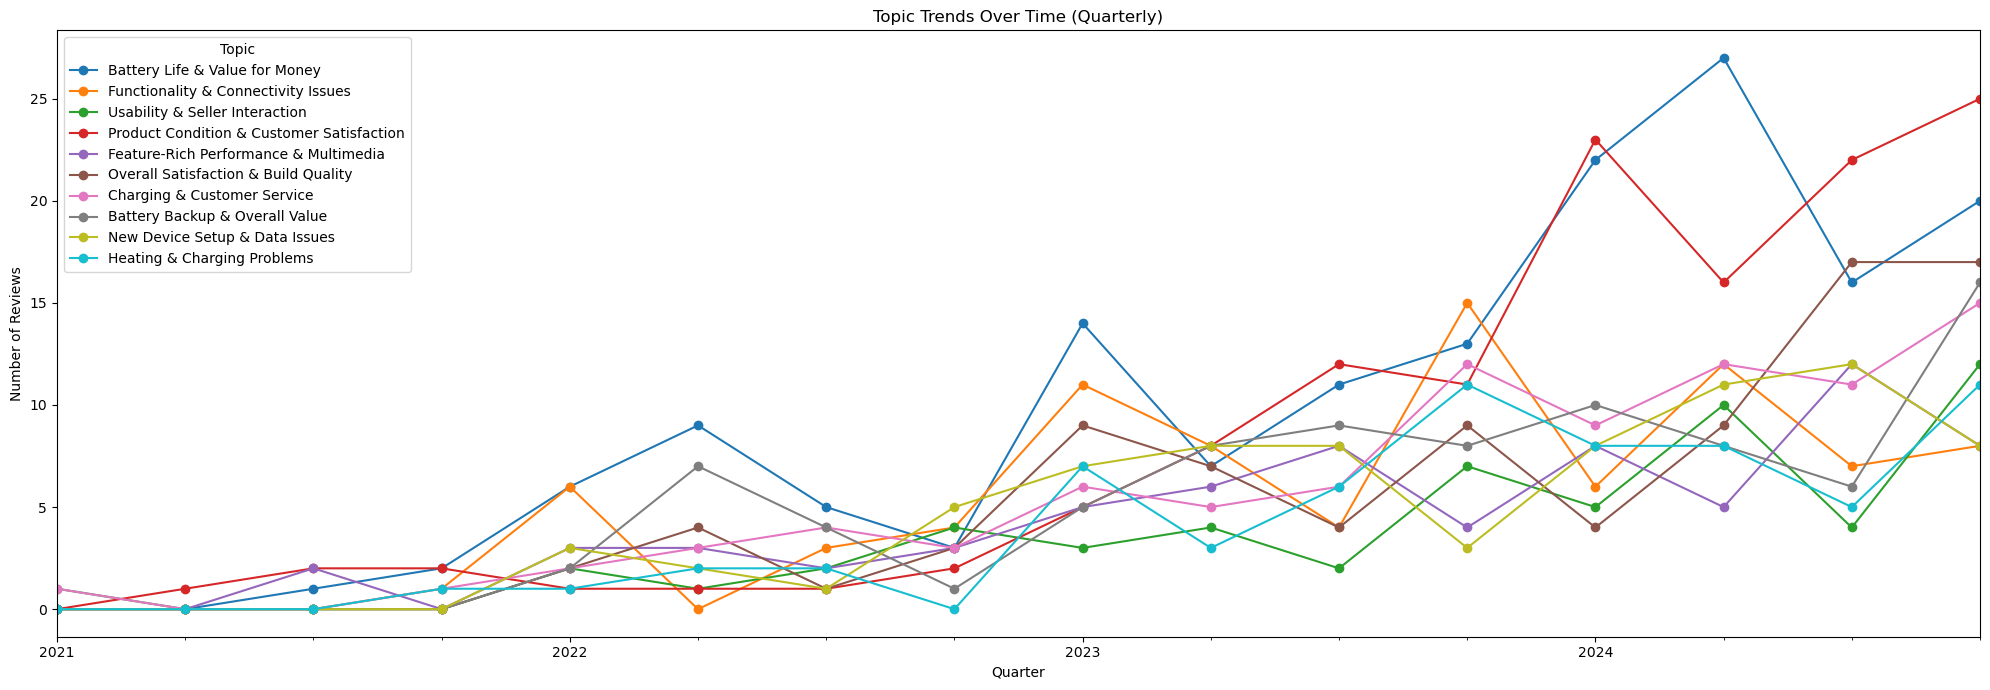

In [49]:

sample_size = 900  # Adjust this to your desired sample size
sampled_df = df1.sample(n=sample_size, random_state=42)  # Use random_state for reproducibility

# Apply topic modeling to the sampled data
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = vectorizer.fit_transform(sampled_df['Cleaned_review'])

lda_model = LatentDirichletAllocation(n_components=10, random_state=42)
lda_model.fit(dtm)

# Print the topics
feature_names = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda_model.components_):
    top_features_ind = topic.argsort()[:-10 - 1:-1]  # Get indices of top 10 words
    top_features = [feature_names[i] for i in top_features_ind]
    print(f"Topic {topic_idx}: {', '.join(top_features)}")

custom_names = {
    0: "Battery Life & Value for Money", 
    1: "Functionality & Connectivity Issues",
    2: "Usability & Seller Interaction",
    3: "Product Condition & Customer Satisfaction",
    4: "Feature-Rich Performance & Multimedia",
    5: "Overall Satisfaction & Build Quality",
    6: "Charging & Customer Service",
    7: "Battery Backup & Overall Value",
    8: "New Device Setup & Data Issues",
    9: "Heating & Charging Problems"
}

# Create a DataFrame for topic assignments over time
topic_trend = pd.DataFrame({
    'Date': sampled_df['Date'],
    'topic': topic_assignments
})
topic_trend = topic_trend.set_index('Date')
topic_trend = pd.get_dummies(topic_trend['topic']).groupby('Date').sum()

# Resample quarterly
topic_trend_quarterly = topic_trend.resample('Q').sum()

# Rename columns as before
topic_trend_quarterly_renamed = topic_trend_quarterly.rename(columns=custom_names)

plt.figure(figsize=(20, 7))
topic_trend_quarterly_renamed.plot(ax=plt.gca(), marker='o')
plt.title('Topic Trends Over Time (Quarterly)')
plt.xlabel('Quarter')
plt.ylabel('Number of Reviews')
plt.legend(title='Topic')
plt.tight_layout()
plt.show()